# 🛒 E-Commerce Customer Analytics

**Objective:** Explore and analyze a fictional e-commerce dataset to extract actionable
marketing insights. This notebook covers:

1. Database setup & data loading (SQL + Python)
2. Exploratory Data Analysis (EDA)
3. Revenue & channel analysis
4. RFM segmentation (Recency, Frequency, Monetary)
5. Customer Lifetime Value (CLV) estimation
6. Key findings & recommendations

**Stack:** Python · Pandas · Matplotlib · Seaborn · SQLite


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

# ── Plot style ───────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})
ACCENT = "#4C72B0"

print("Libraries loaded ✅")


Libraries loaded ✅


## 1  · Data Loading

In [2]:
DB_PATH = "../ecommerce.db"
conn    = sqlite3.connect(DB_PATH)

customers   = pd.read_sql("SELECT * FROM customers",   conn, parse_dates=["signup_date"])
products    = pd.read_sql("SELECT * FROM products",    conn)
orders      = pd.read_sql("SELECT * FROM orders",      conn, parse_dates=["order_date"])
order_items = pd.read_sql("SELECT * FROM order_items", conn)

print(f"Customers:    {len(customers):,}")
print(f"Products:     {len(products):,}")
print(f"Orders:       {len(orders):,}")
print(f"Order items:  {len(order_items):,}")


Customers:    500
Products:     50
Orders:       2,000
Order items:  3,497


In [3]:
print("=== Customers ===")
display(customers.head(3))
print("\n=== Orders ===")
display(orders.head(3))
print("\n=== Order Items ===")
display(order_items.head(3))


=== Customers ===


,customer_id,first_name,last_name,city,segment,signup_date,age,email
0,C0001,Luca,Garcia,Córdoba,Regular,2023-08-24,34,luca.garcia@email.com
1,C0002,Sofia,Gonzalez,Salta,Occasional,2023-02-09,26,sofia.gonzalez@email.com
2,C0003,Gabriela,Sanchez,Córdoba,Occasional,2023-06-10,50,gabriela.sanchez@email.com



=== Orders ===


,order_id,customer_id,order_date,status,channel
0,O00001,C0120,2024-05-29,Returned,Social Media
1,O00002,C0358,2023-02-26,Completed,Paid Search
2,O00003,C0428,2023-05-08,Completed,Organic



=== Order Items ===


,item_id,order_id,product_id,quantity,unit_price,subtotal
0,I000001,O00001,P050,1,54.03,54.03
1,I000002,O00001,P001,3,362.29,1086.87
2,I000003,O00001,P037,3,46.97,140.91


## 2  · Exploratory Data Analysis

In [4]:
# Build master dataframe (completed orders only)
completed = orders[orders["status"] == "Completed"].copy()

master = (
    completed
    .merge(order_items, on="order_id")
    .merge(products[["product_id","product_name","category","price","cost"]], on="product_id")
    .merge(customers[["customer_id","segment","city","age"]], on="customer_id")
)
master["profit"] = (master["unit_price"] - master["cost"]) * master["quantity"]

print(f"Master rows:   {len(master):,}")
print(f"Date range:    {master.order_date.min().date()} → {master.order_date.max().date()}")
print(f"Gross revenue: ${master.subtotal.sum():,.0f}")
print(f"Gross profit:  ${master.profit.sum():,.0f}")
print(f"Profit margin: {master.profit.sum()/master.subtotal.sum()*100:.1f}%")


Master rows:   2,777
Date range:    2023-01-01 → 2024-12-31
Gross revenue: $829,641
Gross profit:  $477,244
Profit margin: 57.5%


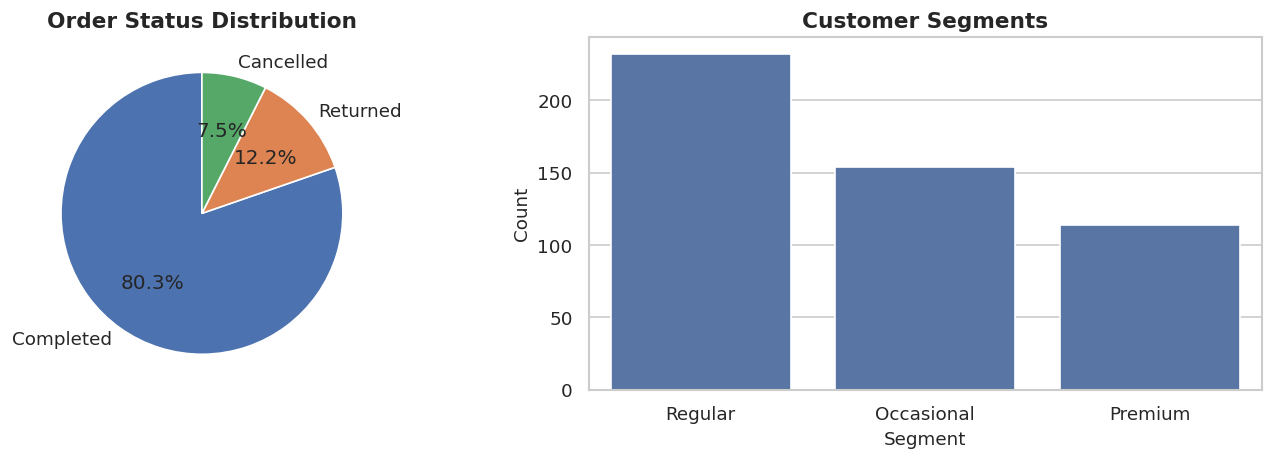

Saved → outputs/01_overview.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Order status
status_counts = orders["status"].value_counts()
axes[0].pie(status_counts, labels=status_counts.index, autopct="%1.1f%%",
            colors=["#4C72B0","#DD8452","#55A868"], startangle=90)
axes[0].set_title("Order Status Distribution")

# Customer segments
seg_counts = customers["segment"].value_counts()
sns.barplot(x=seg_counts.index, y=seg_counts.values, ax=axes[1], color=ACCENT)
axes[1].set_title("Customer Segments")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Segment")

plt.tight_layout()
plt.savefig("../outputs/01_overview.png", bbox_inches="tight")
plt.show()
print("Saved → outputs/01_overview.png")


## 3  · Revenue & Channel Analysis

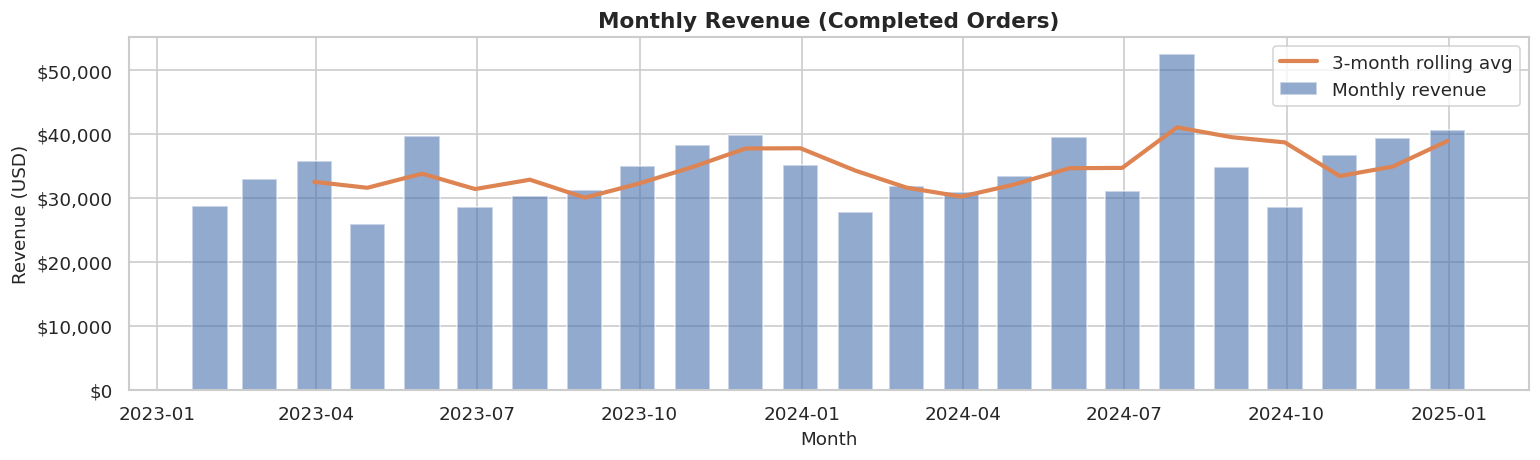

In [6]:
monthly = (
    master.set_index("order_date")
          .resample("ME")["subtotal"]
          .sum()
          .reset_index()
)
monthly.columns = ["month","revenue"]
monthly["rolling_3m"] = monthly["revenue"].rolling(3).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(monthly["month"], monthly["revenue"], width=20, color=ACCENT, alpha=0.6, label="Monthly revenue")
ax.plot(monthly["month"], monthly["rolling_3m"], color="#DD8452", lw=2.5, label="3-month rolling avg")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Monthly Revenue (Completed Orders)")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/02_monthly_revenue.png", bbox_inches="tight")
plt.show()


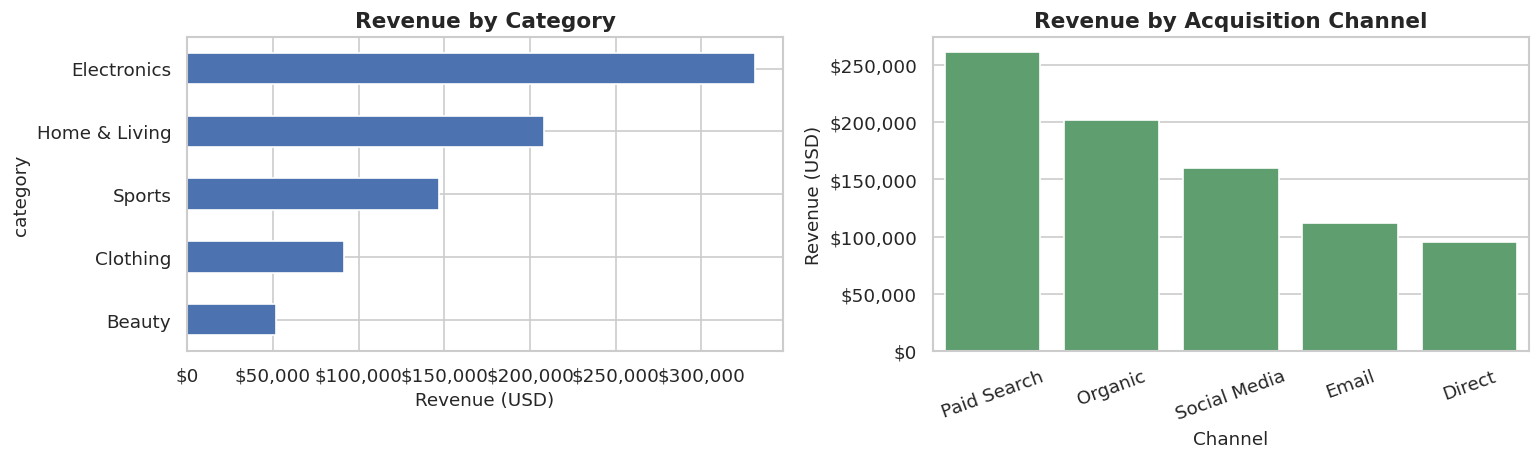

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Revenue by category
cat_rev = master.groupby("category")["subtotal"].sum().sort_values(ascending=True)
cat_rev.plot(kind="barh", ax=axes[0], color=ACCENT)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].set_title("Revenue by Category")
axes[0].set_xlabel("Revenue (USD)")

# Revenue by acquisition channel
ch_rev = master.groupby("channel")["subtotal"].sum().sort_values(ascending=False)
sns.barplot(x=ch_rev.index, y=ch_rev.values, ax=axes[1], color="#55A868")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].set_title("Revenue by Acquisition Channel")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Revenue (USD)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../outputs/03_category_channel.png", bbox_inches="tight")
plt.show()


## 4  · RFM Segmentation

**RFM** is a proven marketing framework that scores each customer on three dimensions:

| Dimension | Definition |
|-----------|-----------|
| **Recency** | Days since last purchase (lower = better) |
| **Frequency** | Number of completed orders (higher = better) |
| **Monetary** | Total amount spent (higher = better) |

Each dimension is scored 1–5 using quintiles. The combined RFM score helps
classify customers into actionable segments.


In [8]:
SNAPSHOT = master["order_date"].max()

rfm = (
    master.groupby("customer_id")
    .agg(
        last_order  = ("order_date", "max"),
        frequency   = ("order_id",   "nunique"),
        monetary    = ("subtotal",   "sum"),
    )
    .reset_index()
)
rfm["recency"] = (SNAPSHOT - rfm["last_order"]).dt.days

# Score 1-5 (recency: lower days = higher score)
rfm["R"] = pd.qcut(rfm["recency"],  5, labels=[5,4,3,2,1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5]).astype(int)
rfm["RFM_Score"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)
rfm["RFM_Total"] = rfm[["R","F","M"]].sum(axis=1)

def rfm_segment(row):
    r, f, m = row["R"], row["F"], row["M"]
    if r >= 4 and f >= 4 and m >= 4:  return "Champions"
    if r >= 3 and f >= 3:              return "Loyal Customers"
    if r >= 4 and f <= 2:              return "New Customers"
    if r <= 2 and f >= 3:              return "At Risk"
    if r <= 2 and f <= 2:              return "Lost"
    return "Potential Loyalists"

rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

print(rfm["Segment"].value_counts().to_string())
rfm.head()


Segment
Loyal Customers        120
Lost                   105
At Risk                 73
Champions               73
New Customers           46
Potential Loyalists     27


,customer_id,last_order,frequency,monetary,recency,R,F,M,RFM_Score,RFM_Total,Segment
0,C0001,2024-11-30,2,2982.94,31,5,1,5,515,11,New Customers
1,C0003,2023-09-05,2,798.84,483,1,1,2,112,4,Lost
2,C0004,2024-02-10,3,2157.37,325,1,2,4,124,7,Lost
3,C0005,2024-10-02,3,1647.15,90,4,2,3,423,9,New Customers
4,C0006,2024-10-19,8,1709.43,73,4,5,3,453,12,Loyal Customers


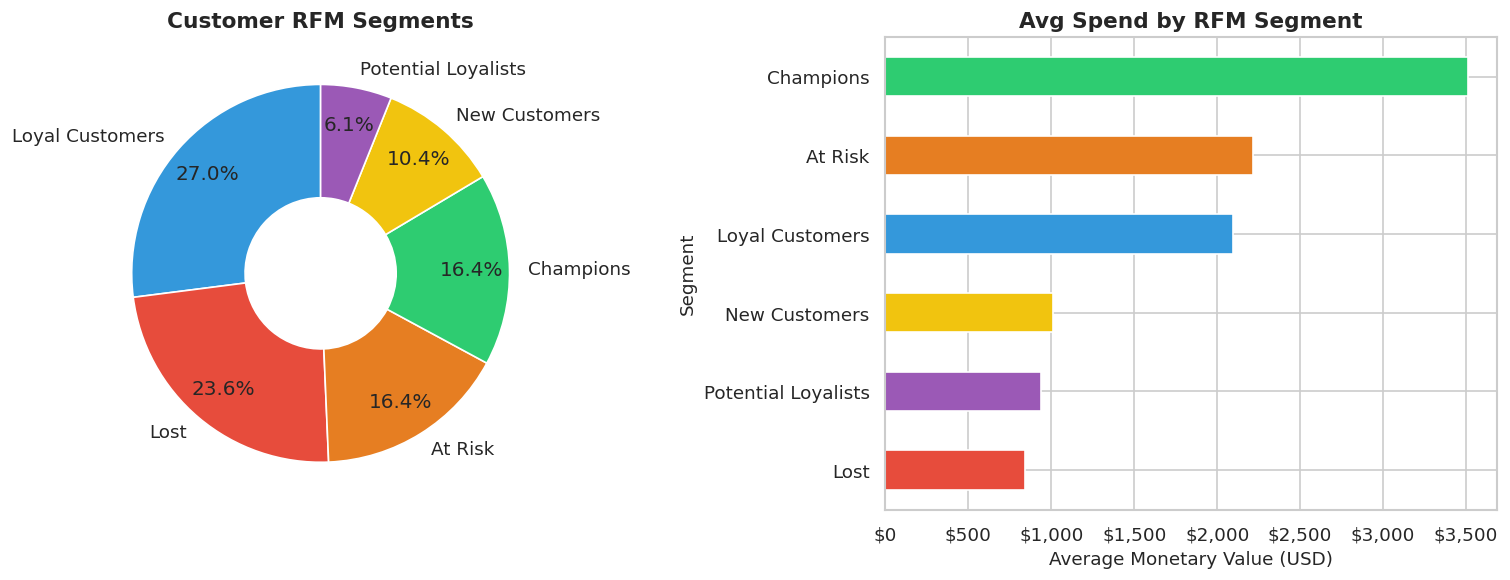

In [9]:
seg_palette = {
    "Champions":          "#2ecc71",
    "Loyal Customers":    "#3498db",
    "Potential Loyalists":"#9b59b6",
    "New Customers":      "#f1c40f",
    "At Risk":            "#e67e22",
    "Lost":               "#e74c3c",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Segment distribution (donut)
seg_counts = rfm["Segment"].value_counts()
colors     = [seg_palette[s] for s in seg_counts.index]
wedges, texts, autotexts = axes[0].pie(
    seg_counts, labels=seg_counts.index, autopct="%1.1f%%",
    colors=colors, startangle=90, pctdistance=0.8,
    wedgeprops={"width": 0.6}
)
axes[0].set_title("Customer RFM Segments")

# Avg monetary by segment
seg_monetary = rfm.groupby("Segment")["monetary"].mean().sort_values(ascending=True)
seg_monetary.plot(kind="barh", ax=axes[1],
                  color=[seg_palette[s] for s in seg_monetary.index])
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].set_title("Avg Spend by RFM Segment")
axes[1].set_xlabel("Average Monetary Value (USD)")

plt.tight_layout()
plt.savefig("../outputs/04_rfm_segments.png", bbox_inches="tight")
plt.show()


## 5  · Customer Lifetime Value (CLV)

Simple CLV formula:

> **CLV = Avg Order Value × Purchase Frequency × Customer Lifespan (years)**

We estimate lifespan from each customer's activity window.


CLV Statistics:
count      $444.00
mean     $1,868.56
std      $1,361.54
min         $21.28
25%        $802.34
50%      $1,620.78
75%      $2,659.09
max      $8,317.76


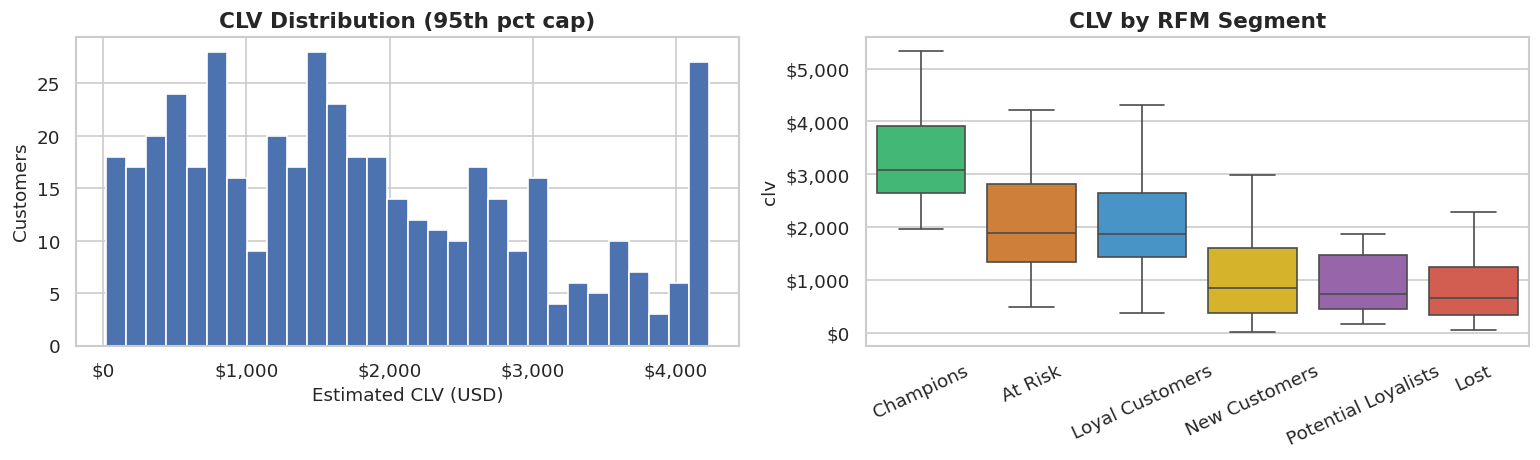

In [10]:
clv_df = (
    master.groupby("customer_id")
    .agg(
        total_revenue = ("subtotal",   "sum"),
        total_orders  = ("order_id",   "nunique"),
        first_order   = ("order_date", "min"),
        last_order    = ("order_date", "max"),
    )
    .reset_index()
)

clv_df["lifespan_years"] = (
    (clv_df["last_order"] - clv_df["first_order"]).dt.days / 365
).clip(lower=0.08)  # min ~1 month

clv_df["avg_order_value"]    = clv_df["total_revenue"] / clv_df["total_orders"]
clv_df["purchase_frequency"] = clv_df["total_orders"]  / clv_df["lifespan_years"]
clv_df["clv"]                = (clv_df["avg_order_value"]
                                 * clv_df["purchase_frequency"]
                                 * clv_df["lifespan_years"]).round(2)

print("CLV Statistics:")
print(clv_df["clv"].describe().apply(lambda x: f"${x:,.2f}").to_string())

# Merge with segment
clv_df = clv_df.merge(rfm[["customer_id","Segment"]], on="customer_id")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# CLV distribution
axes[0].hist(clv_df["clv"].clip(upper=clv_df["clv"].quantile(0.95)),
             bins=30, color=ACCENT, edgecolor="white")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].set_title("CLV Distribution (95th pct cap)")
axes[0].set_xlabel("Estimated CLV (USD)")
axes[0].set_ylabel("Customers")

# CLV by segment (box)
order_by_median = clv_df.groupby("Segment")["clv"].median().sort_values(ascending=False).index
sns.boxplot(data=clv_df, x="Segment", y="clv", order=order_by_median,
            palette=seg_palette, ax=axes[1],
            showfliers=False)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].set_title("CLV by RFM Segment")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig("../outputs/05_clv.png", bbox_inches="tight")
plt.show()


## 6  · Key Findings & Recommendations

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | **Paid Search** drives the most revenue but also competes closely with **Social Media** | A/B test creatives; shift budget toward highest-CLV channels |
| 2 | **Champions** represent a small % of customers but outsized revenue | Launch a VIP loyalty program with early access & exclusive discounts |
| 3 | **At Risk** customers have high historical spend but low recency | Re-engagement email campaign with personalized offers |
| 4 | **Electronics** leads revenue; **Beauty** has the highest return rate | Improve product descriptions & sizing guides to reduce returns |
| 5 | New customer cohorts show strong purchase frequency in first 60 days | Trigger onboarding email sequence within the first week of signup |

---
*Dataset: synthetic data generated for portfolio purposes.*  
*Author: [Your Name] — [LinkedIn] — [GitHub]*
